# Training Loop — Scenario A (essenziale)

Carichiamo il modello salvato nel notebook 02 e lo addestriamo per 8 epoche.

## Cosa fa questo notebook
1. Ricarica modello, tokenizer, image processor dallo snapshot iniziale
2. Ricrea i DataLoader (train + val)
3. Definisce ottimizzatore (AdamW) e training loop
4. Per ogni epoca: train pass → validation pass → checkpoint save
5. Plot delle learning curves alla fine

## Iperparametri
- Epoche: 8
- Learning rate: 5e-5 (standard per fine-tuning di transformer pre-addestrati)
- Optimizer: AdamW (con weight decay 0.01)
- Batch size: 32

## Note
- Usiamo `torch.amp.autocast` con bf16 per sfruttare i tensor core della 5070:
  training ~1.5x piu' veloce e uso VRAM ridotto, senza degradazione di qualita'.
- bf16 invece di fp16 per stabilita' numerica (i tensor core Blackwell lo supportano).
- Salviamo un checkpoint per ogni epoca in `checkpoints/epoch_NN/`.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from transformers import (
    VisionEncoderDecoderModel,
    GPT2Tokenizer,
    ViTImageProcessor,
)
from tqdm.auto import tqdm
import time
import json

# Riproducibilita'
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Path del progetto
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "flickr8k"
IMAGES_DIR = DATA_DIR / "Images"
SPLIT_FILE = DATA_DIR / "captions_with_split.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
INITIAL_MODEL_DIR = CHECKPOINT_DIR / "model_initial"

# Iperparametri (Scenario A)
NUM_EPOCHS = 8
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
NUM_WORKERS = 0  # Windows-friendly come nel notebook 02
MAX_LENGTH = 30
GRAD_CLIP = 1.0  # clipping del gradiente per stabilita'

print(f"\n=== Iperparametri ===")
print(f"Epoche: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max length: {MAX_LENGTH}")
print(f"Gradient clipping: {GRAD_CLIP}")

Device: cuda
GPU: NVIDIA GeForce RTX 5070

=== Iperparametri ===
Epoche: 8
Learning rate: 5e-05
Weight decay: 0.01
Batch size: 32
Max length: 30
Gradient clipping: 1.0


In [2]:
# Ricarica modello, tokenizer, image_processor dallo snapshot iniziale
print(f"Caricamento modello da: {INITIAL_MODEL_DIR}")
model = VisionEncoderDecoderModel.from_pretrained(INITIAL_MODEL_DIR)
tokenizer = GPT2Tokenizer.from_pretrained(INITIAL_MODEL_DIR)
image_processor = ViTImageProcessor.from_pretrained(INITIAL_MODEL_DIR)

# Reimposta il pad_token (al caricamento si perde questa configurazione)
tokenizer.pad_token = tokenizer.eos_token

model = model.to(device)
print(f"Modello caricato su {device}")
print(f"Parametri: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")


# Ridefiniamo la classe Dataset (identica al notebook 02)
class Flickr8kCaptionsDataset(Dataset):
    def __init__(self, df_split, images_dir, image_processor, tokenizer, max_length=30):
        self.df = df_split.reset_index(drop=True)
        self.images_dir = images_dir
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.images_dir / row['image']
        image = Image.open(img_path).convert("RGB")
        pixel_values = self.image_processor(image, return_tensors="pt")["pixel_values"].squeeze(0)
        
        text = self.tokenizer.bos_token + " " + row['caption'] + " " + self.tokenizer.eos_token
        encoding = self.tokenizer(
            text, padding="max_length", max_length=self.max_length,
            truncation=True, return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100
        
        return {"pixel_values": pixel_values, "labels": labels}


# Carica split
df = pd.read_csv(SPLIT_FILE)
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']

train_dataset = Flickr8kCaptionsDataset(train_df, IMAGES_DIR, image_processor, tokenizer, MAX_LENGTH)
val_dataset = Flickr8kCaptionsDataset(val_df, IMAGES_DIR, image_processor, tokenizer, MAX_LENGTH)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"\nTrain: {len(train_dataset)} esempi, {len(train_loader)} batch")
print(f"Val:   {len(val_dataset)} esempi, {len(val_loader)} batch")

Caricamento modello da: c:\dev\image-captioning\checkpoints\model_initial
Modello caricato su cuda
Parametri: 239.2M

Train: 30000 esempi, 938 batch
Val:   5000 esempi, 157 batch


In [3]:
# Optimizer: AdamW con weight decay
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Verifica supporto bf16 sulla GPU (tutte le RTX 30/40/50 lo supportano)
use_amp = torch.cuda.is_bf16_supported()
amp_dtype = torch.bfloat16 if use_amp else torch.float32
print(f"Mixed precision (bfloat16): {'attiva' if use_amp else 'non disponibile'}")


def train_one_epoch(model, loader, optimizer, device, epoch):
    """Una epoca di training. Ritorna la loss media."""
    model.train()
    total_loss = 0.0
    n_batches = len(loader)
    
    pbar = tqdm(loader, desc=f"Epoca {epoch} [train]", leave=False)
    for batch in pbar:
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Forward in mixed precision
        with torch.amp.autocast(device_type='cuda', dtype=amp_dtype, enabled=use_amp):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
        
        # Backward
        loss.backward()
        
        # Gradient clipping (stabilizza il training di transformer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader, device):
    """Validazione: ritorna la loss media sul set."""
    model.eval()
    total_loss = 0.0
    n_batches = len(loader)
    
    for batch in tqdm(loader, desc="Validazione", leave=False):
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)
        
        with torch.amp.autocast(device_type='cuda', dtype=amp_dtype, enabled=use_amp):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
        
        total_loss += loss.item()
    
    return total_loss / n_batches


print("Funzioni di train e validazione definite.")

Mixed precision (bfloat16): attiva
Funzioni di train e validazione definite.


In [4]:
# Storia del training (per i grafici dopo)
history = {
    'train_loss': [],
    'val_loss': [],
    'epoch_time_sec': [],
}

print(f"=== Inizio training: {NUM_EPOCHS} epoche ===\n")
overall_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, device, epoch)
    
    # Validation
    val_loss = evaluate(model, val_loader, device)
    
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['epoch_time_sec'].append(epoch_time)
    
    print(f"Epoca {epoch:2d}/{NUM_EPOCHS} | "
          f"train loss: {train_loss:.4f} | "
          f"val loss: {val_loss:.4f} | "
          f"tempo: {epoch_time/60:.1f} min")
    
    # Salva checkpoint
    ckpt_dir = CHECKPOINT_DIR / f"epoch_{epoch:02d}"
    model.save_pretrained(ckpt_dir)
    
    # Salva anche history per non perderla in caso di crash
    with open(CHECKPOINT_DIR / "history.json", "w") as f:
        json.dump(history, f, indent=2)

total_time = time.time() - overall_start
print(f"\n=== Training completato in {total_time/60:.1f} minuti ===")
print(f"Loss finale - train: {history['train_loss'][-1]:.4f}, val: {history['val_loss'][-1]:.4f}")

=== Inizio training: 8 epoche ===



Epoca 1 [train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validazione:   0%|          | 0/157 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 30, 'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3}
Your generation config was originally created from the model config, but the model config has changed since then. Unless you pass the `generation_config` argument to this model's `generate` calls, they will revert to the legacy behavior where the base `generate` parameterization is loaded from the model config instead. To avoid this behavior and this warning, we recommend you to overwrite the generation config model attribute before calling the model's `save_pretrained`, preferably also removing any generation kwargs from the model config. This warning will be raised to an exception 

Epoca  1/8 | train loss: 2.2182 | val loss: 2.0121 | tempo: 6.1 min


...

Epoca  7/8 | train loss: 1.1645 | val loss: 2.1260 | tempo: 5.5 min


Epoca 8 [train]:   0%|          | 0/938 [00:00<?, ?it/s]

Validazione:   0%|          | 0/157 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 30, 'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3}
Your generation config was originally created from the model config, but the model config has changed since then. Unless you pass the `generation_config` argument to this model's `generate` calls, they will revert to the legacy behavior where the base `generate` parameterization is loaded from the model config instead. To avoid this behavior and this warning, we recommend you to overwrite the generation config model attribute before calling the model's `save_pretrained`, preferably also removing any generation kwargs from the model config. This warning will be raised to an exception 

Epoca  8/8 | train loss: 1.0721 | val loss: 2.1972 | tempo: 5.5 min

=== Training completato in 44.4 minuti ===
Loss finale - train: 1.0721, val: 2.1972


## Learning curves e analisi

Visualizziamo l'andamento di train/val loss per identificare visivamente
il punto di overfitting (val loss minima).

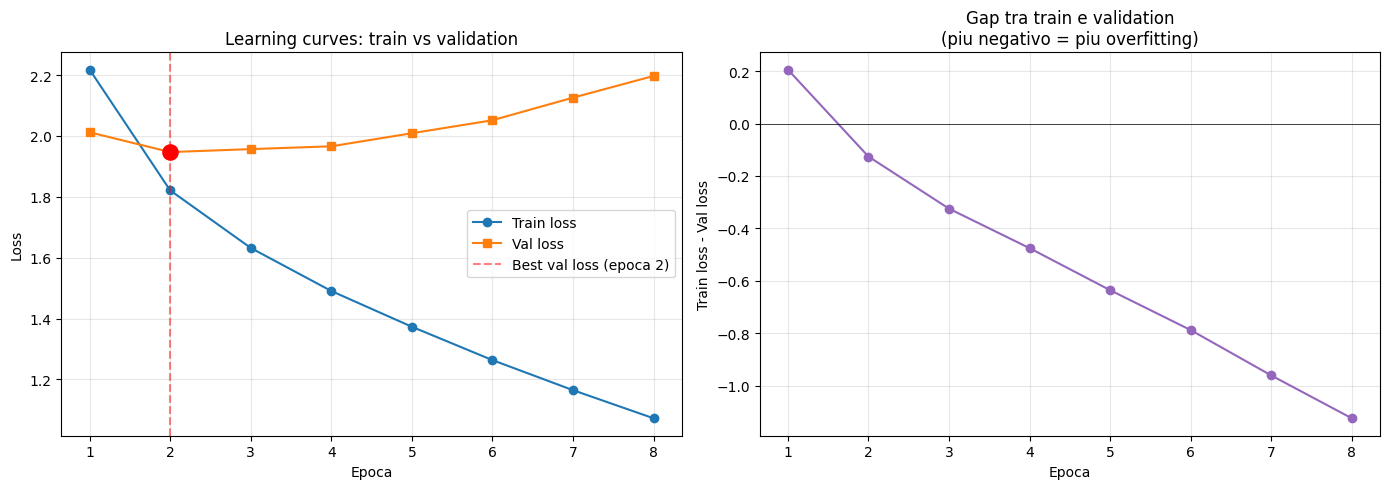

=== Riassunto training ===
Migliore epoca:         2 (val loss = 1.9470)
Train loss alla best:   1.8212
Train loss finale:      1.0721
Val loss finale:        2.1972
Gap train-val finale:   -1.1251  (negativo grande = overfitting)
Tempo totale:           44.3 min

>>> Per inference useremo il checkpoint dell'epoca 2 <<<


In [5]:
import matplotlib.pyplot as plt

# Carica history (anche se e' gia' in memoria, leggiamo dal file per essere sicuri)
with open(CHECKPOINT_DIR / "history.json", "r") as f:
    history = json.load(f)

epochs = list(range(1, len(history['train_loss']) + 1))
best_epoch = int(np.argmin(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: train vs val loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'o-', label='Train loss', color='tab:blue')
ax.plot(epochs, history['val_loss'], 's-', label='Val loss', color='tab:orange')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5,
           label=f'Best val loss (epoca {best_epoch})')
ax.scatter([best_epoch], [best_val_loss], color='red', s=120, zorder=5)
ax.set_xlabel('Epoca')
ax.set_ylabel('Loss')
ax.set_title('Learning curves: train vs validation')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: gap (train - val) per visualizzare l'overfitting
ax = axes[1]
gap = [t - v for t, v in zip(history['train_loss'], history['val_loss'])]
ax.plot(epochs, gap, 'o-', color='tab:purple')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Epoca')
ax.set_ylabel('Train loss - Val loss')
ax.set_title('Gap tra train e validation\n(piu negativo = piu overfitting)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "learning_curves.png", dpi=120, bbox_inches='tight')
plt.show()

# Riassunto numerico
print("=== Riassunto training ===")
print(f"Migliore epoca:         {best_epoch} (val loss = {best_val_loss:.4f})")
print(f"Train loss alla best:   {history['train_loss'][best_epoch-1]:.4f}")
print(f"Train loss finale:      {history['train_loss'][-1]:.4f}")
print(f"Val loss finale:        {history['val_loss'][-1]:.4f}")
print(f"Gap train-val finale:   {history['train_loss'][-1] - history['val_loss'][-1]:.4f}  (negativo grande = overfitting)")
print(f"Tempo totale:           {sum(history['epoch_time_sec'])/60:.1f} min")
print(f"\n>>> Per inference useremo il checkpoint dell'epoca {best_epoch} <<<")

## Conclusioni del notebook 03

**Risultato:** training completato in 44 minuti su RTX 5070.

**Osservazione chiave:** overfitting evidente a partire dall'epoca 3. La val loss
raggiunge il minimo all'epoca 2 (1.95) e risale progressivamente fino a 2.20.
La train loss continua invece a scendere (1.07), indicando che il modello sta
memorizzando il training set invece di generalizzare.

**Best checkpoint per inference:** `checkpoints/epoch_02/`

**Strade per migliorare (Scenario B futuro):**
- Early stopping basato su val loss
- Learning rate scheduler (cosine decay)
- Data augmentation sulle immagini (flip orizzontale, color jitter)
- Dropout aumentato nella cross-attention
- Salvataggio incrementale del solo "best model" invece di ogni epoca

**Prossimo notebook (04):** valutazione qualitativa e quantitativa con BLEU
sul checkpoint `epoch_02`. Solo dopo aver visto i risultati ha senso decidere
se passare allo Scenario B.

In [6]:
import shutil

best_epoch = int(np.argmin(history['val_loss'])) + 1
src_dir = CHECKPOINT_DIR / f"epoch_{best_epoch:02d}"
dst_dir = CHECKPOINT_DIR / "best"

if dst_dir.exists():
    shutil.rmtree(dst_dir)
shutil.copytree(src_dir, dst_dir)

# Aggiungi metadata su quale epoca era il best
best_info = {
    "best_epoch": best_epoch,
    "best_val_loss": float(history['val_loss'][best_epoch - 1]),
    "best_train_loss": float(history['train_loss'][best_epoch - 1]),
    "all_epochs_val_loss": history['val_loss'],
    "all_epochs_train_loss": history['train_loss'],
}
with open(CHECKPOINT_DIR / "best_info.json", "w") as f:
    json.dump(best_info, f, indent=2)

print(f"✅ Best model copiato in: {dst_dir}")
print(f"   Epoca: {best_epoch}")
print(f"   Val loss: {best_info['best_val_loss']:.4f}")

✅ Best model copiato in: c:\dev\image-captioning\checkpoints\best
   Epoca: 2
   Val loss: 1.9470
